# Market Segmentation For Airlines
Market segmentation is a strategy that divides a broad target market of customers into smaller, more similar groups, and then designs a marketing strategy specifically for each group. Clustering is a common technique for market segmentation since it automatically finds similar groups given a data set.

In this problem, we'll see how clustering can be used to find similar groups of customers who belong to an airline's frequent flyer program. The airline is trying to learn more about its customers so that it can target different customer segments with different types of mileage offers.

The file AirlinesCluster.csv contains information on 3,999 members of the frequent flyer program. This data comes from the textbook "Data Mining for Business Intelligence," by Galit Shmueli, Nitin R. Patel, and Peter C. Bruce. For more information, see the website for the book.

There are seven different variables in the dataset, described below:


*   **Balance** = number of miles eligible for award travel
*   **QualMiles** = number of miles qualifying for TopFlight status
*   **BonusMiles**= number of miles earned from non-flight bonus transactions in the past 12 months
*   **BonusTrans** = number of non-flight bonus transactions in the past 12 months
*   **FlightMiles** = number of flight miles in the past 12 months
*   **FlightTrans** = number of flight transactions in the past 12 months
*   **DaysSinceEnroll** = number of days since enrolled in the frequent flyer program

# Problem 1.1 - Normalizing the Data

Read the dataset AirlinesCluster.csv into Python and call it "airlines".

Looking at the summary of airlines, which TWO variables have (on average) the smallest values? Which TWO variables have (on average) the largest values?

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

np.random.seed(42)
from google.colab import files
uploaded = files.upload()


Saving AirlinesCluster.csv to AirlinesCluster.csv


In [ ]:
# Load Data
airlines = pd.read_csv("AirlinesCluster.csv")
print (airlines.head())

   Balance  QualMiles  BonusMiles  BonusTrans  FlightMiles  FlightTrans  \
0    28143          0         174           1            0            0   
1    19244          0         215           2            0            0   
2    41354          0        4123           4            0            0   
3    14776          0         500           1            0            0   
4    97752          0       43300          26         2077            4   

   DaysSinceEnroll  
0             7000  
1             6968  
2             7034  
3             6952  
4             6935  


In [ ]:
print(airlines.describe())

            Balance     QualMiles     BonusMiles  BonusTrans   FlightMiles  \
count  3.999000e+03   3999.000000    3999.000000  3999.00000   3999.000000   
mean   7.360133e+04    144.114529   17144.846212    11.60190    460.055764   
std    1.007757e+05    773.663804   24150.967826     9.60381   1400.209171   
min    0.000000e+00      0.000000       0.000000     0.00000      0.000000   
25%    1.852750e+04      0.000000    1250.000000     3.00000      0.000000   
50%    4.309700e+04      0.000000    7171.000000    12.00000      0.000000   
75%    9.240400e+04      0.000000   23800.500000    17.00000    311.000000   
max    1.704838e+06  11148.000000  263685.000000    86.00000  30817.000000   

       FlightTrans  DaysSinceEnroll  
count  3999.000000       3999.00000  
mean      1.373593       4118.55939  
std       3.793172       2065.13454  
min       0.000000          2.00000  
25%       0.000000       2330.00000  
50%       0.000000       4096.00000  
75%       1.000000       5790.5

## Problem 1.2 - Normalizing the Data

In this problem, we will normalize our data before we run the clustering algorithms. Why is it important to normalize the data before clustering?


*   If we don't normalize the data, the clustering algorithms will not work.
*   If we don't normalize the data, it will be hard to interpret the results of the clustering.
*   If we don't normalize the data, the clustering will be dominated by the variables that are on a larger scale.
*   If we don't normalize the data, the clustering will be dominated by the variables that are on a smaller scale.




## Problem 1.3 - Normalizing the Data

Let's go ahead and normalize our data and create a normalized data frame called "airlinesNorm".

If you look at the summary of airlinesNorm, you should see that all of the variables now have mean zero.

In the normalized data, which variable has the largest maximum value? Which variable has the smallest minimum value?

In [ ]:
# Normalize Data
airlines_norm = (airlines - airlines.mean()) / airlines.std()

In [ ]:
list(zip(airlines.columns, airlines_norm.max(axis = 0)))

[('Balance', 16.18681130105777),
 ('QualMiles', 14.223084250404423),
 ('BonusMiles', 10.20829291655933),
 ('BonusTrans', 7.746727280076486),
 ('FlightMiles', 21.680292385902458),
 ('FlightTrans', 13.61035065098924),
 ('DaysSinceEnroll', 2.0228418675762376)]

In [ ]:
list(zip(airlines.columns, airlines_norm.min(axis = 0)))

[('Balance', -0.7303482205984386),
 ('QualMiles', -0.18627539224903517),
 ('BonusMiles', -0.7099030703415415),
 ('BonusTrans', -1.208051811609478),
 ('FlightMiles', -0.32856217010843447),
 ('FlightTrans', -0.36212258481736315),
 ('DaysSinceEnroll', -1.993361357169234)]

## Problem 2.1 - Hierarchical Clustering

Compute the distances between data points (using euclidean distance) and then run the Hierarchical clustering algorithm on the normalized data. It may take a few minutes for the commands to finish since the dataset has a large number of observations for hierarchical clustering.

Then, plot the dendrogram of the hierarchical clustering process. Suppose the airline is looking for somewhere between 2 and 10 clusters. According to the dendrogram, which of the following is a potential choice for the number of clusters? Select all that apply.
*   2
*   3
*   6
*   7



In [ ]:
# Hierarchical Clustering
airline_dist = pdist(airlines_norm, metric="euclidean")
airline_dist = np.round(airline_dist, 7)

# linkage_matrix = linkage(airline_dist, method="ward")

from scipy.spatial.distance import squareform
linkage_matrix = linkage(airline_dist, method="ward")

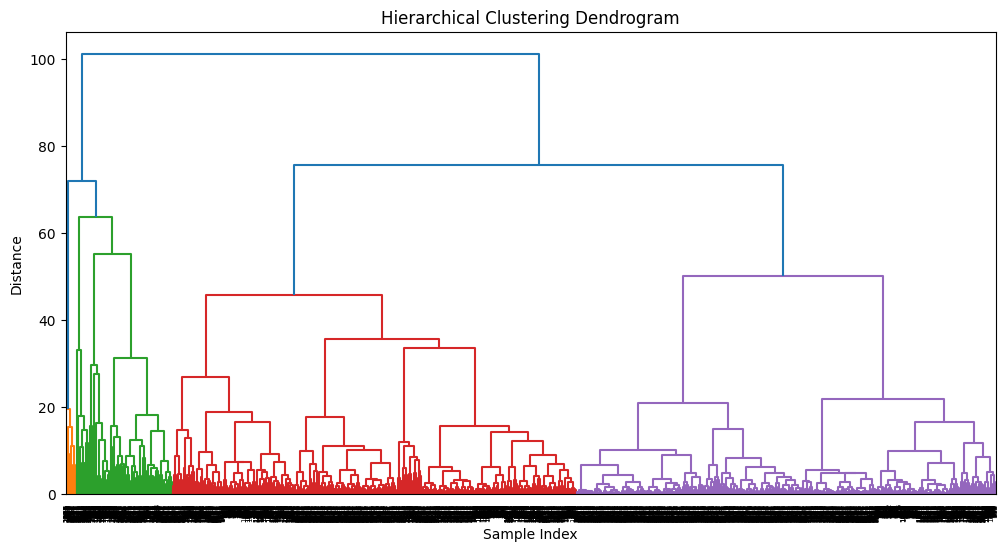

In [ ]:
# Plot Dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()

## Problem 2.2 - Hierarchical Clustering

Suppose that after looking at the dendrogram and discussing with the marketing department, the airline decides to proceed with 5 clusters. Divide the data points into 5 clusters by using the cutree function. How many data points are in Cluster 1?

In [ ]:
# Cut Tree into Clusters
cluster_groups = fcluster(linkage_matrix, 5, criterion='maxclust')
print(pd.Series(cluster_groups).value_counts())

5    1801
4    1737
3     360
2      53
1      48
Name: count, dtype: int64


## Problem 2.3 - Hierarchical Clustering

Now, compare the average values in each of the variables for the 5 clusters (the centroids of the clusters). You may want to compute the average values of the unnormalized data so that it is easier to interpret.

Compared to the other clusters, Cluster 1 has the largest average values in which variables (if any)?

In [ ]:
# Compute Cluster Means
cluster_df = pd.DataFrame(airlines, index=range(len(airlines)))
cluster_df["Cluster"] = cluster_groups
cluster_means = cluster_df.groupby("Cluster").mean()
print(cluster_means)


               Balance    QualMiles    BonusMiles  BonusTrans  FlightMiles  \
Cluster                                                                      
1        135318.020833  5870.062500  16406.000000   12.645833   974.770833   
2        154830.603774   490.716981  32137.018868   33.471698  8752.622642   
3        204316.227778   144.711111  36265.022222   19.802778  2286.719444   
4         79910.013241   123.694876  26735.156592   16.832470   148.672424   
5         37353.074403     0.882288   3651.923931    4.246530   137.491394   

         FlightTrans  DaysSinceEnroll  
Cluster                                
1           3.270833      4320.375000  
2          23.679245      4046.830189  
3           6.744444      4744.158333  
4           0.483592      4727.468048  
5           0.451416      3402.970572  


How would you describe the customers in Cluster 1?
*   Relatively new customers who don't use the airline very often.
*   Median frequency travels and primarily takes elite status flights.
*   Customers who have accumulated a large amount of miles, and the ones with the largest number of flight transactions.
*   Relatively loyal customers who have not traveled that much.
*   Loyal customers who have accumulated a lot of points and awards to be redeemed through both flight and non-flight transactions.

## Problem 2.4 - Hierarchical Clustering

Compared to the other clusters, Cluster 2 has the largest average values in which variables (if any)?

How would you describe the customers in Cluster 2?
*   Relatively new customers who don't use the airline very often.
*   Median frequency travels and primarily takes elite status flights.
*   Customers who have accumulated a large amount of miles, and the ones with the largest number of flight transactions.
*   Relatively loyal customers who have not traveled that much.
*   Loyal customers who have accumulated a lot of points and awards to be redeemed through both flight and non-flight transactions.

## Problem 2.5 - Hierarchical Clustering

Compared to the other clusters, Cluster 3 has the largest average values in which variables (if any)?

How would you describe the customers in Cluster 3?
*   Relatively new customers who don't use the airline very often.
*   Median frequency travels and primarily takes elite status flights.
*   Customers who have accumulated a large amount of miles, and the ones with the largest number of flight transactions.
*   Relatively loyal customers who have not traveled that much.
*   Loyal customers who have accumulated a lot of points and awards to be redeemed through both flight and non-flight transactions.

## Problem 2.6 - Hierarchical Clustering

How would you describe the customers in Cluster 4?
*   Relatively new customers who don't use the airline very often.
*   Median frequency travels and primarily takes elite status flights.
*   Customers who have accumulated a large amount of miles, and the ones with the largest number of flight transactions.
*   Relatively loyal customers who have not traveled that much.
*   Loyal customers who have accumulated a lot of points and awards to be redeemed through both flight and non-flight transactions.

## Problem 2.7 - Hierarchical Clustering

Compared to the other clusters, Cluster 5 has the smallest average values in which variables (if any)?

How would you describe the customers in Cluster 5?
*   Relatively new customers who don't use the airline very often.
*   Median frequency travels and primarily takes elite status flights.
*   Customers who have accumulated a large amount of miles, and the ones with the largest number of flight transactions.
*   Relatively loyal customers who have not traveled that much.
*   Loyal customers who have accumulated a lot of points and awards to be redeemed through both flight and non-flight transactions.

## Problem 3.1 - K-Means Clustering

Now run the k-means clustering algorithm on the normalized data, again creating 5 clusters. Set the seed to 88 right before running the clustering algorithm, and set the argument max_iter to 1000.

How many clusters have more than 1,000 observations?

In [ ]:
# K-Means Clustering
np.random.seed(88)
kmeans = KMeans(n_clusters=5, max_iter=1000, random_state=88)
kmeans.fit(airlines_norm)
print(pd.Series(kmeans.labels_).value_counts())

1    1656
0    1384
4     764
2     138
3      57
Name: count, dtype: int64


## Problem 3.2 - K-Means Clustering

Now, compare the cluster centroids to each other either by dividing the data points into groups, or by looking at the output of cluster_centers_, (Note that the output of cluster_centers_ will be for the normalized data. If you want to look at the average values for the unnormalized data, you need to look at the original data like we did for hierarchical clustering.)

Do you expect Cluster 1 of the K-Means clustering output to necessarily be similar to Cluster 1 of the Hierarchical clustering output?
*   Yes, because the clusters are displayed in order of size, so the largest cluster will always be first.
*   Yes, because the clusters are displayed according to the properties of the centroid, so the cluster order will be similar.
*   No, because cluster ordering is not meaningful in either k-means clustering or hierarchical clustering.
*   No, because the clusters produced by the k-means algorithm will never be similar to the clusters produced by the Hierarchical algorithm.


In [ ]:
# K-Means Cluster Centers
print(pd.DataFrame(kmeans.cluster_centers_, columns=airlines.columns))

    Balance  QualMiles  BonusMiles  BonusTrans  FlightMiles  FlightTrans  \
0 -0.160773  -0.115719   -0.337711   -0.248536    -0.176737    -0.193026   
1 -0.352850  -0.140702   -0.427833   -0.409779    -0.200867    -0.216369   
2  0.982400   0.371123    0.634051    1.766311     3.862209     4.134897   
3  0.400998   6.978766    0.084959    0.072507     0.342603     0.382521   
4  0.849765  -0.073076    1.420431    1.015427     0.032606     0.043518   

   DaysSinceEnroll  
0         0.821740  
1        -0.888292  
2         0.245104  
3        -0.119306  
4         0.398647  
